<a href="https://colab.research.google.com/github/thecodemaster152/Brief-guide-to-tensor-flow/blob/main/00_tensorFlow_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("lets start")

lets start


In [ ]:
# importing tensorflow
import tensorflow as tf

##Creating Tensor

At first creating tensor with tf.constant()

In [ ]:
scalar = tf.constant(7)
scalar

<tf.Tensor: shape=(), dtype=int32, numpy=7>

In [ ]:
#checking number of dimension of a tensor
scalar.ndim

0

In [ ]:
vector = tf.constant([10,10])
vector

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([10, 10], dtype=int32)>

notice here, shape of vector is (2,) ansd not just (2) bcoz, shape of tensor is stored in tuple always

In [ ]:
vector.ndim

1

In [ ]:
matrix = tf.constant([[2,3],[3,2]])
matrix.shape

TensorShape([2, 2])

In [ ]:
matrix.ndim

2

In [ ]:
#creating another matrix
another_matrix = tf.constant([[1,2,3],[1,2,3],[1,2,3]], dtype = tf.float32)

In [ ]:
another_matrix

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]], dtype=float32)>

In [ ]:
another_matrix.ndim

2

This was all about tf.constant now lets see tf.variable()


In [ ]:
changeable_tensor = tf.Variable([2,3])
changeable_tensor

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([2, 3], dtype=int32)>

In [ ]:
changeable_tensor[0] = 4

TypeError: 'ResourceVariable' object does not support item assignment

what we did above is wrong, we cant use "=" but we have to do somehting like this


In [ ]:
changeable_tensor[0].assign(4)

<tf.Variable 'UnreadVariable' shape=(2,) dtype=int32, numpy=array([4, 3], dtype=int32)>

##Creating Random Tensor

Tensor with arbitary size and random  numbers

In [ ]:
random_t1 = tf.random.Generator.from_seed(42)            #set seed form reproducibility
print(random_t1)

Okay whats this, and why  did these two line not print a tensor of random number?

    well thats because
    tf.random.Generator.from_seed(42)
    
    This creates a random number generator object in TensorFlow.
    Think of it like creating a machine that can generate random numbers.

    so by running this, we basically build a machine that will create the random number not the number yet

    from_seed(42), is just like random_state = 42 from classical ML,  it creates the same type of random number everytime

  So now from this machine we will generate that random number

  it simply means that generator object is in random_t1

In [ ]:
random_tensor1 = random_t1.normal(shape = (3,3))
print(random_tensor1)

tf.Tensor(
[[ 0.35215586  1.0294334   1.127859  ]
 [-0.8251682  -1.0670931  -0.6990595 ]
 [-0.6695724  -1.0871812   0.45619673]], shape=(3, 3), dtype=float32)


now lets change two things, first  seed number, second normal to uniform distribution

In [ ]:
random_t2 = tf.random.Generator.from_seed(41)
random_tensor2 = random_t2.normal(shape = (3,3))
print(random_tensor2)            # everything same as above just the seed number is changed

tf.Tensor(
[[ 0.31662667 -1.4391748   0.58923835]
 [-1.4268045  -0.7565803  -0.06854702]
 [ 0.07595026 -1.2573844  -0.23193763]], shape=(3, 3), dtype=float32)


In [ ]:
random_tensor3 = random_t1.uniform(shape = (3,3))
print(random_tensor3)             #everything same from t1 just the distribution is changed

tf.Tensor(
[[0.56495655 0.63836706 0.05003309]
 [0.81855416 0.77826595 0.3525461 ]
 [0.8897736  0.73193777 0.3169284 ]], shape=(3, 3), dtype=float32)


I hope the diffenrence is clearly visilble in all 3 tensors

##Shuffling the tensor

why do we need shuffling of tensor

    better gradient updates
    less biased batches
    more stable learning

Not shuffling causes biased learning during training

Shuffling is especially important for:

training datasets

stochastic gradient descent

mini-batch training

It ensures the model learns true patterns, not ordering artifacts.

In [ ]:
# Shuffle a tensor (valuable for when you want to shuffle your data)
not_shuffled1 = tf.constant([[10, 7],
                            [3, 4],
                            [2, 5]])
# Gets different results each time
tf.random.shuffle(not_shuffled1)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 3,  4],
       [ 2,  5],
       [10,  7]], dtype=int32)>

now just look below, you will understand the concept of seed and shuffle better

In [ ]:
not_shuffled2 = tf.constant([[5,7],
                            [3, 4],
                            [5,6]])

In [ ]:
tf.random.set_seed(42)          #gloabal seed
tf.random.shuffle(not_shuffled2 , seed = 42)            #operation seed

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[5, 7],
       [3, 4],
       [5, 6]], dtype=int32)>

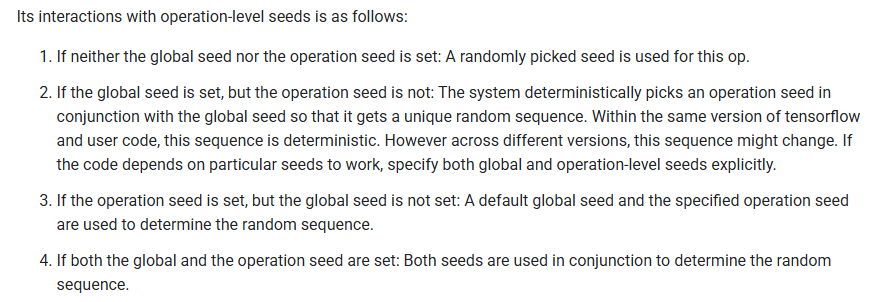

In [ ]:
tf.random.shuffle(not_shuffled2)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[5, 7],
       [3, 4],
       [5, 6]], dtype=int32)>

Run these two multiple times and you will see the one fixed using seed, always gives the same shuffled output, but the other one wihtout seed, always gives a different shuffled output

##Creating tensor from numpy array